In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/cardio_train (1).csv",sep=';',engine='python')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [3]:
df.isnull().sum()

,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0
smoke,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [20]:
df['age_years'] = (df['age'] / 365.25).astype(int)
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47


In [19]:
print('Height distribution:')
print(df['height'].describe())

print('\nWeight distribution:')
print(df['weight'].describe())

print('\nSystolic Blood Pressure (ap_hi) distribution:')
print(df['ap_hi'].describe())

print('\nDiastolic Blood Pressure (ap_lo) distribution:')
print(df['ap_lo'].describe())


Height distribution:
count    70000.000000
mean       164.359229
std          8.210126
min         55.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        250.000000
Name: height, dtype: float64

Weight distribution:
count    70000.000000
mean        74.205690
std         14.395757
min         10.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64

Systolic Blood Pressure (ap_hi) distribution:
count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: ap_hi, dtype: float64

Diastolic Blood Pressure (ap_lo) distribution:
count    70000.000000
mean        96.630414
std        188.472530
min        -70.000000
25%         80.000000
50%         80.000000
75%         90.000000
max      11000.000000
Name: ap_lo, dtype: float64


In [25]:
df_filtered = df[(df['ap_lo'] > 0) & (df['ap_hi'] > 0) & (df['ap_hi'] >= df['ap_lo']) &
                 (df['ap_hi'] < 250) & (df['ap_lo'] < 140)]

df_filtered = df_filtered[(df_filtered['height'] > 100) & (df_filtered['height'] < 220)]
df_filtered = df_filtered[(df_filtered['weight'] > 30) & (df_filtered['weight'] < 200)]

print(f"Original dataset size: {len(df)}")
print(f"Dataset size after filtering: {len(df_filtered)}")
df = df_filtered.copy()

print('\nSystolic Blood Pressure (ap_hi) distribution after filtering:')
print(df['ap_hi'].describe())

print('\nDiastolic Blood Pressure (ap_lo) distribution after filtering:')
print(df['ap_lo'].describe())

print('\nHeight distribution after filtering:')
print(df['height'].describe())

print('\nWeight distribution after filtering:')
print(df['weight'].describe())

Original dataset size: 68648
Dataset size after filtering: 68648

Systolic Blood Pressure (ap_hi) distribution after filtering:
count    68648.000000
mean       126.650157
std         16.660005
min         16.000000
25%        120.000000
50%        120.000000
75%        140.000000
max        240.000000
Name: ap_hi, dtype: float64

Diastolic Blood Pressure (ap_lo) distribution after filtering:
count    68648.000000
mean        81.255084
std          9.494515
min          1.000000
25%         80.000000
50%         80.000000
75%         90.000000
max        130.000000
Name: ap_lo, dtype: float64

Height distribution after filtering:
count    68648.000000
mean       164.397215
std          7.963435
min        104.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        207.000000
Name: height, dtype: float64

Weight distribution after filtering:
count    68648.00000
mean        74.11403
std         14.28737
min         31.00000
25%         65.00000
50%         72

/tmp/ipykernel_1559/488669296.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cardio', data=df, palette='viridis')


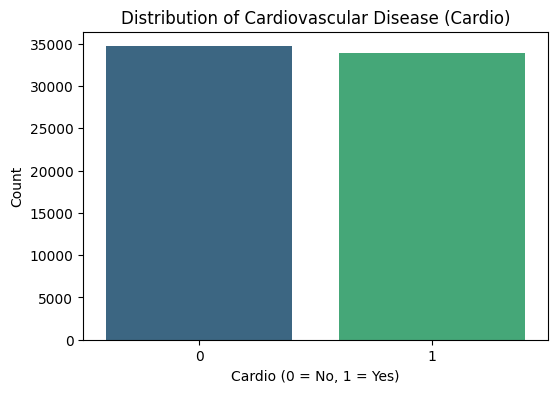

In [24]:
plt.figure(figsize=(6, 4))
sns.countplot(x='cardio', data=df, palette='viridis')
plt.title('Distribution of Cardiovascular Disease (Cardio)')
plt.xlabel('Cardio (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_1559/366108662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='magma', ax=axes[i])
/tmp/ipykernel_1559/366108662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='magma', ax=axes[i])
/tmp/ipykernel_1559/366108662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='magma', ax=axes[i])
/tmp/ipykernel_1559/366108662.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` vari

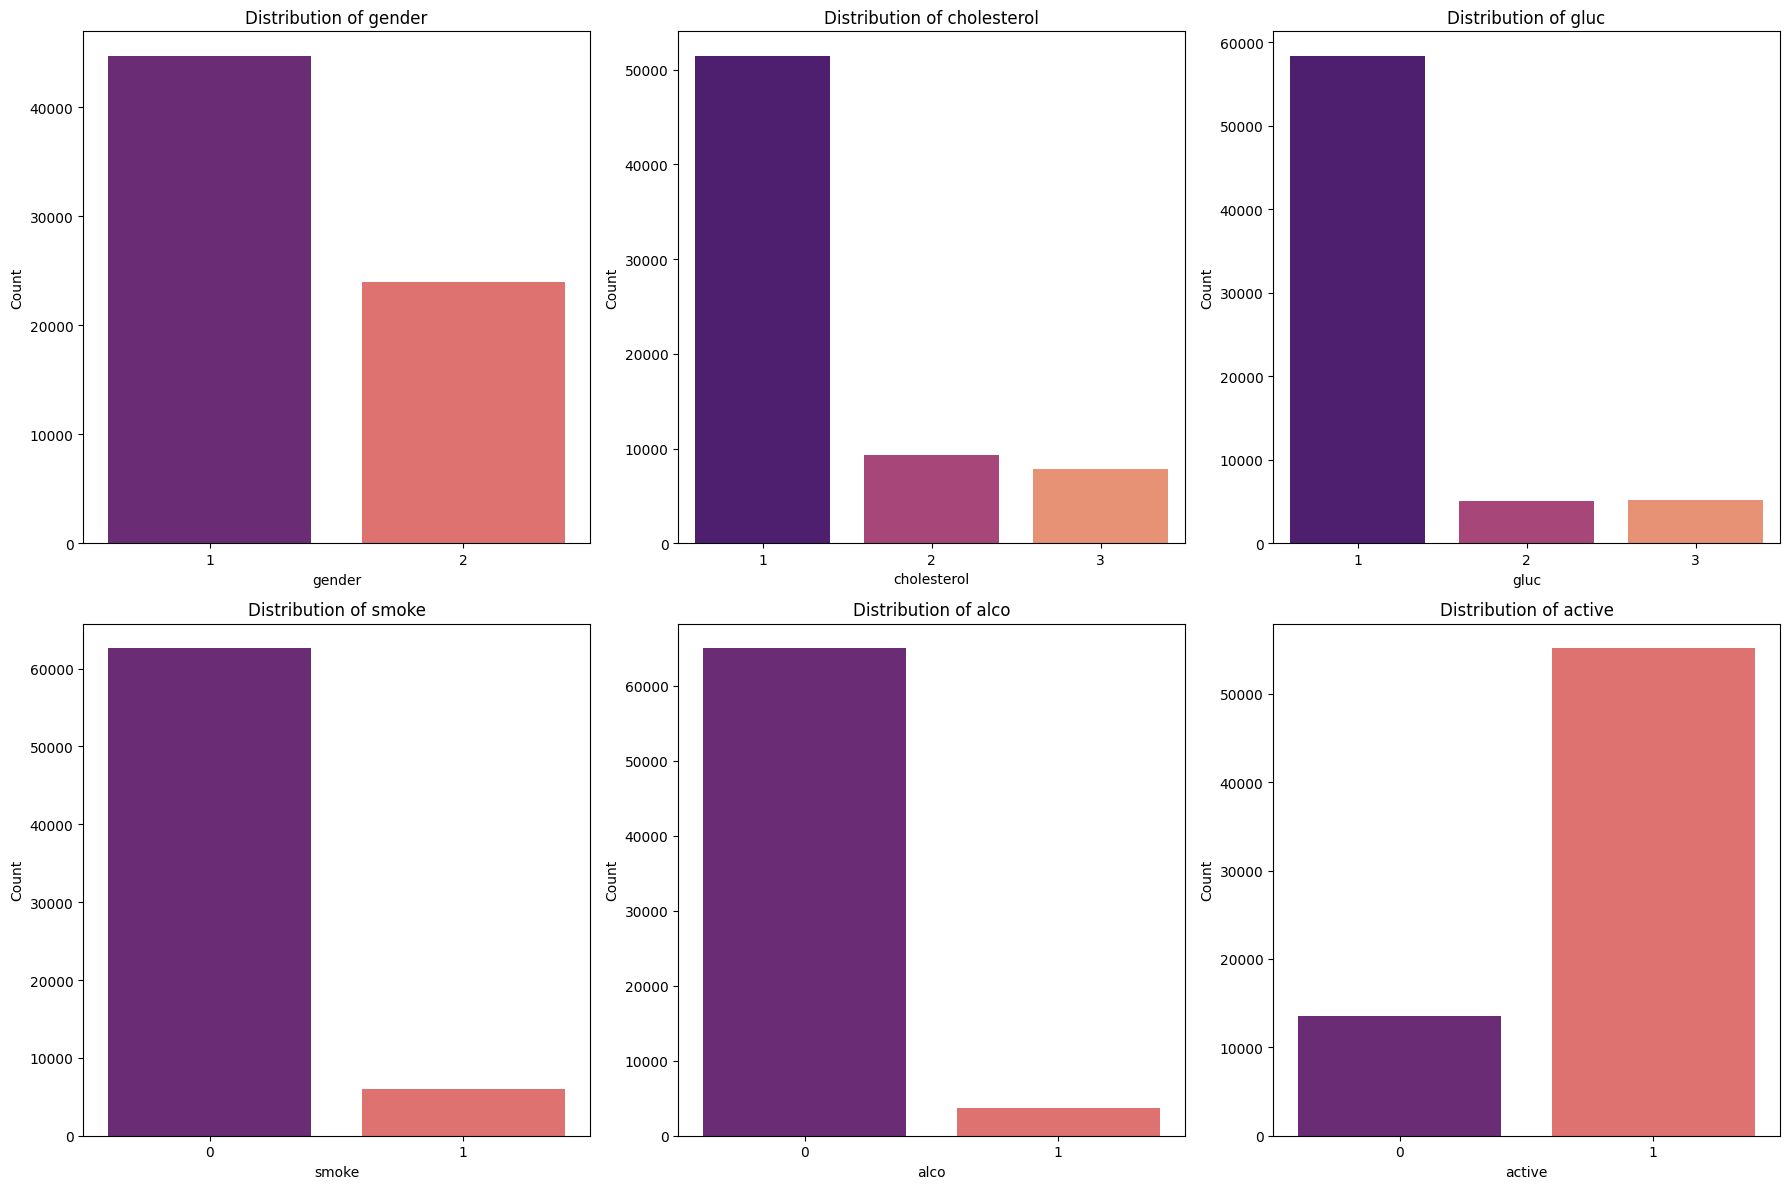

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

for i, col in enumerate(categorical_features):
    sns.countplot(x=col, data=df, palette='magma', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

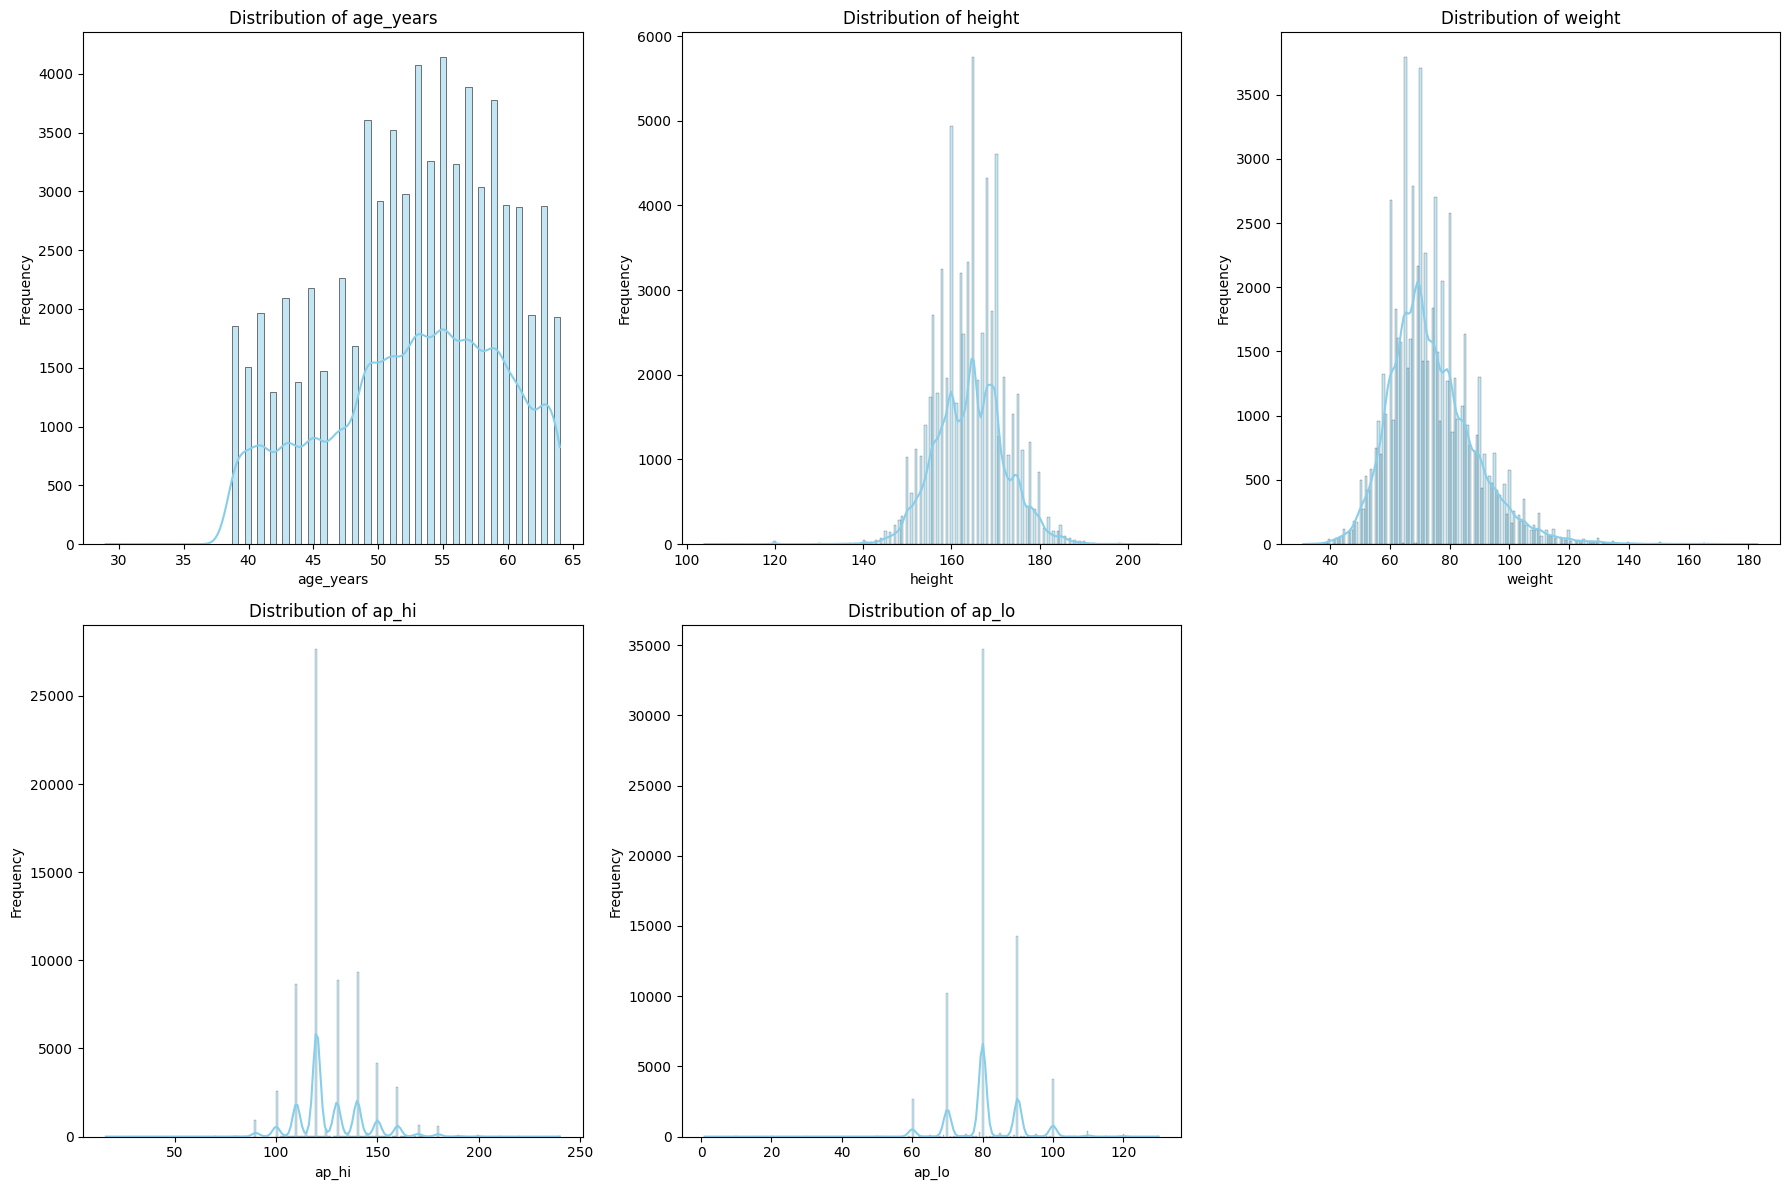

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
numerical_features = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

if len(numerical_features) < len(axes):
    for j in range(len(numerical_features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

/tmp/ipykernel_1559/3820329143.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cardio', y=col, data=df, ax=axes[i], palette='pastel')
/tmp/ipykernel_1559/3820329143.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cardio', y=col, data=df, ax=axes[i], palette='pastel')
/tmp/ipykernel_1559/3820329143.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='cardio', y=col, data=df, ax=axes[i], palette='pastel')
/tmp/ipykernel_1559/3820329143.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

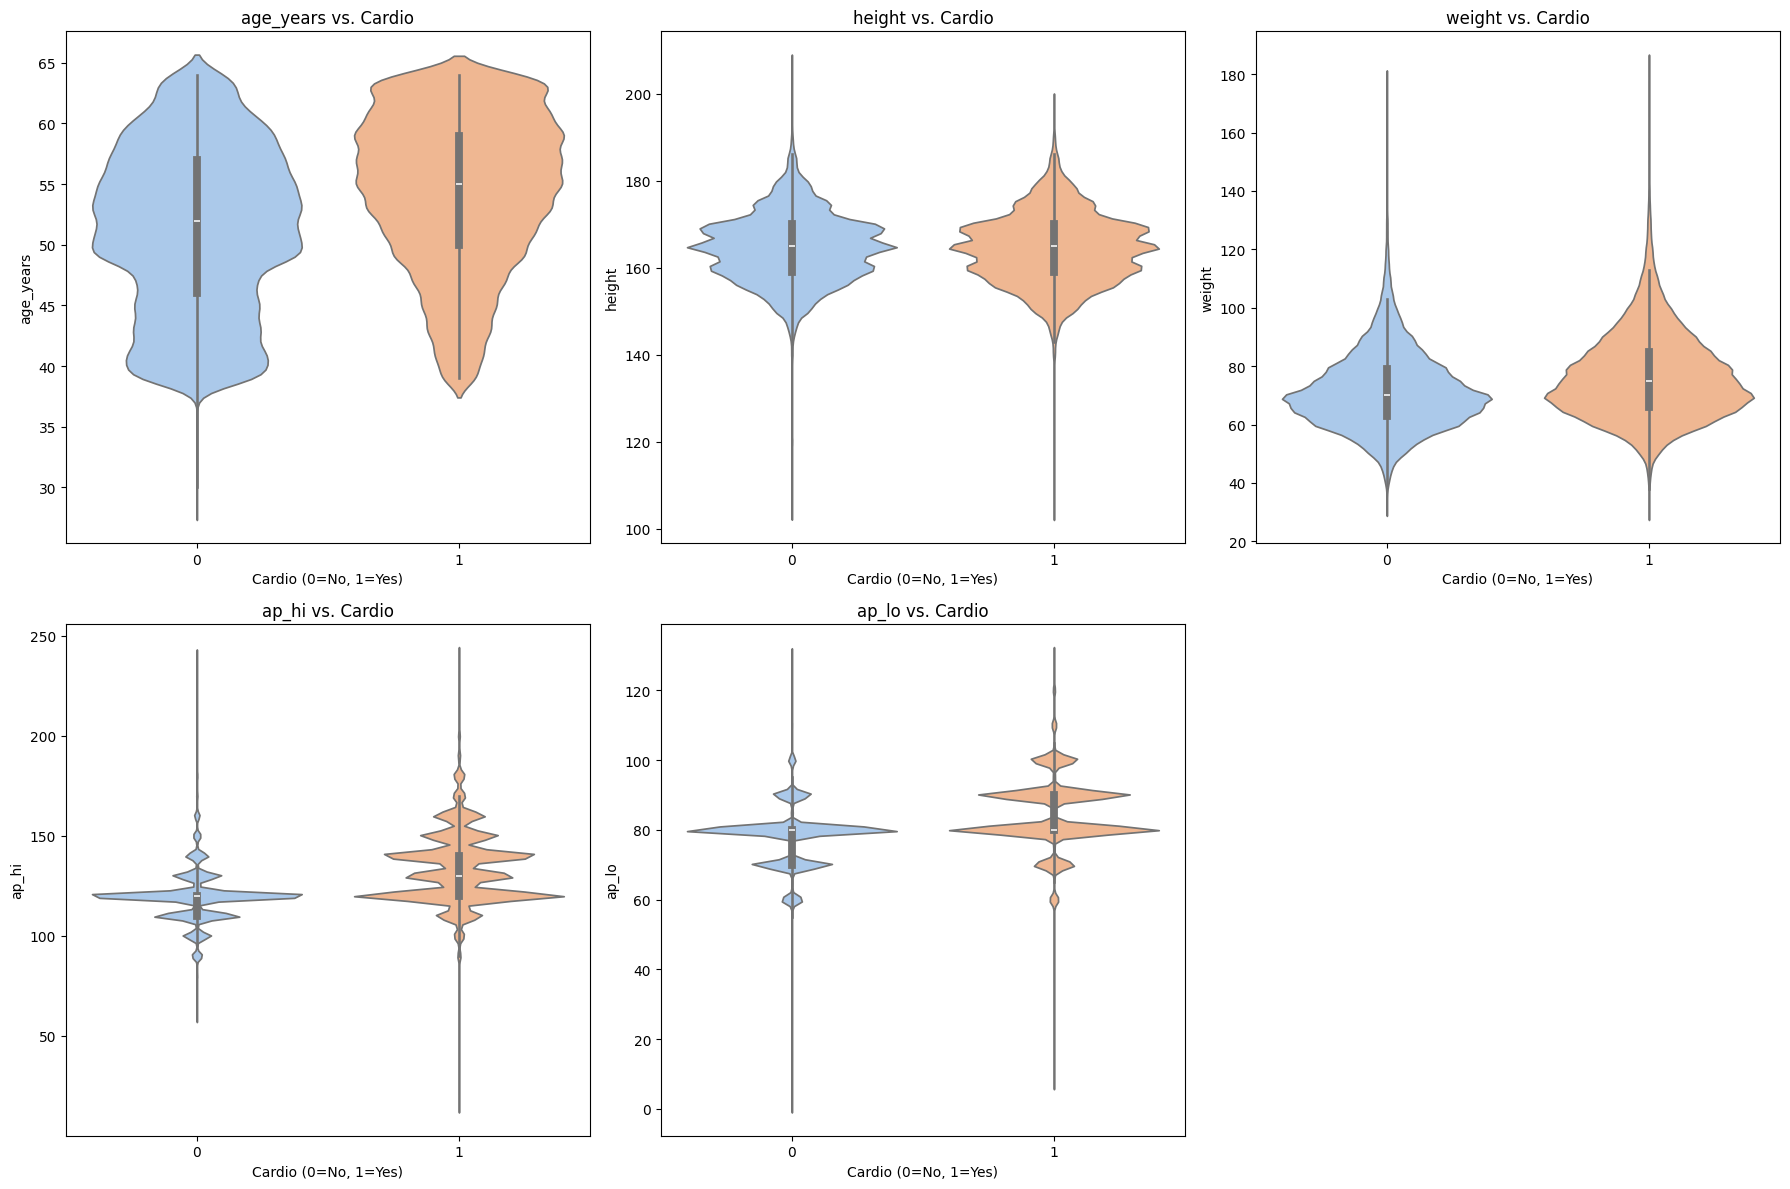

In [26]:
numerical_features = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_features):
    sns.violinplot(x='cardio', y=col, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(f'{col} vs. Cardio')
    axes[i].set_xlabel('Cardio (0=No, 1=Yes)')
    axes[i].set_ylabel(col)

if len(numerical_features) < len(axes):
    for j in range(len(numerical_features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

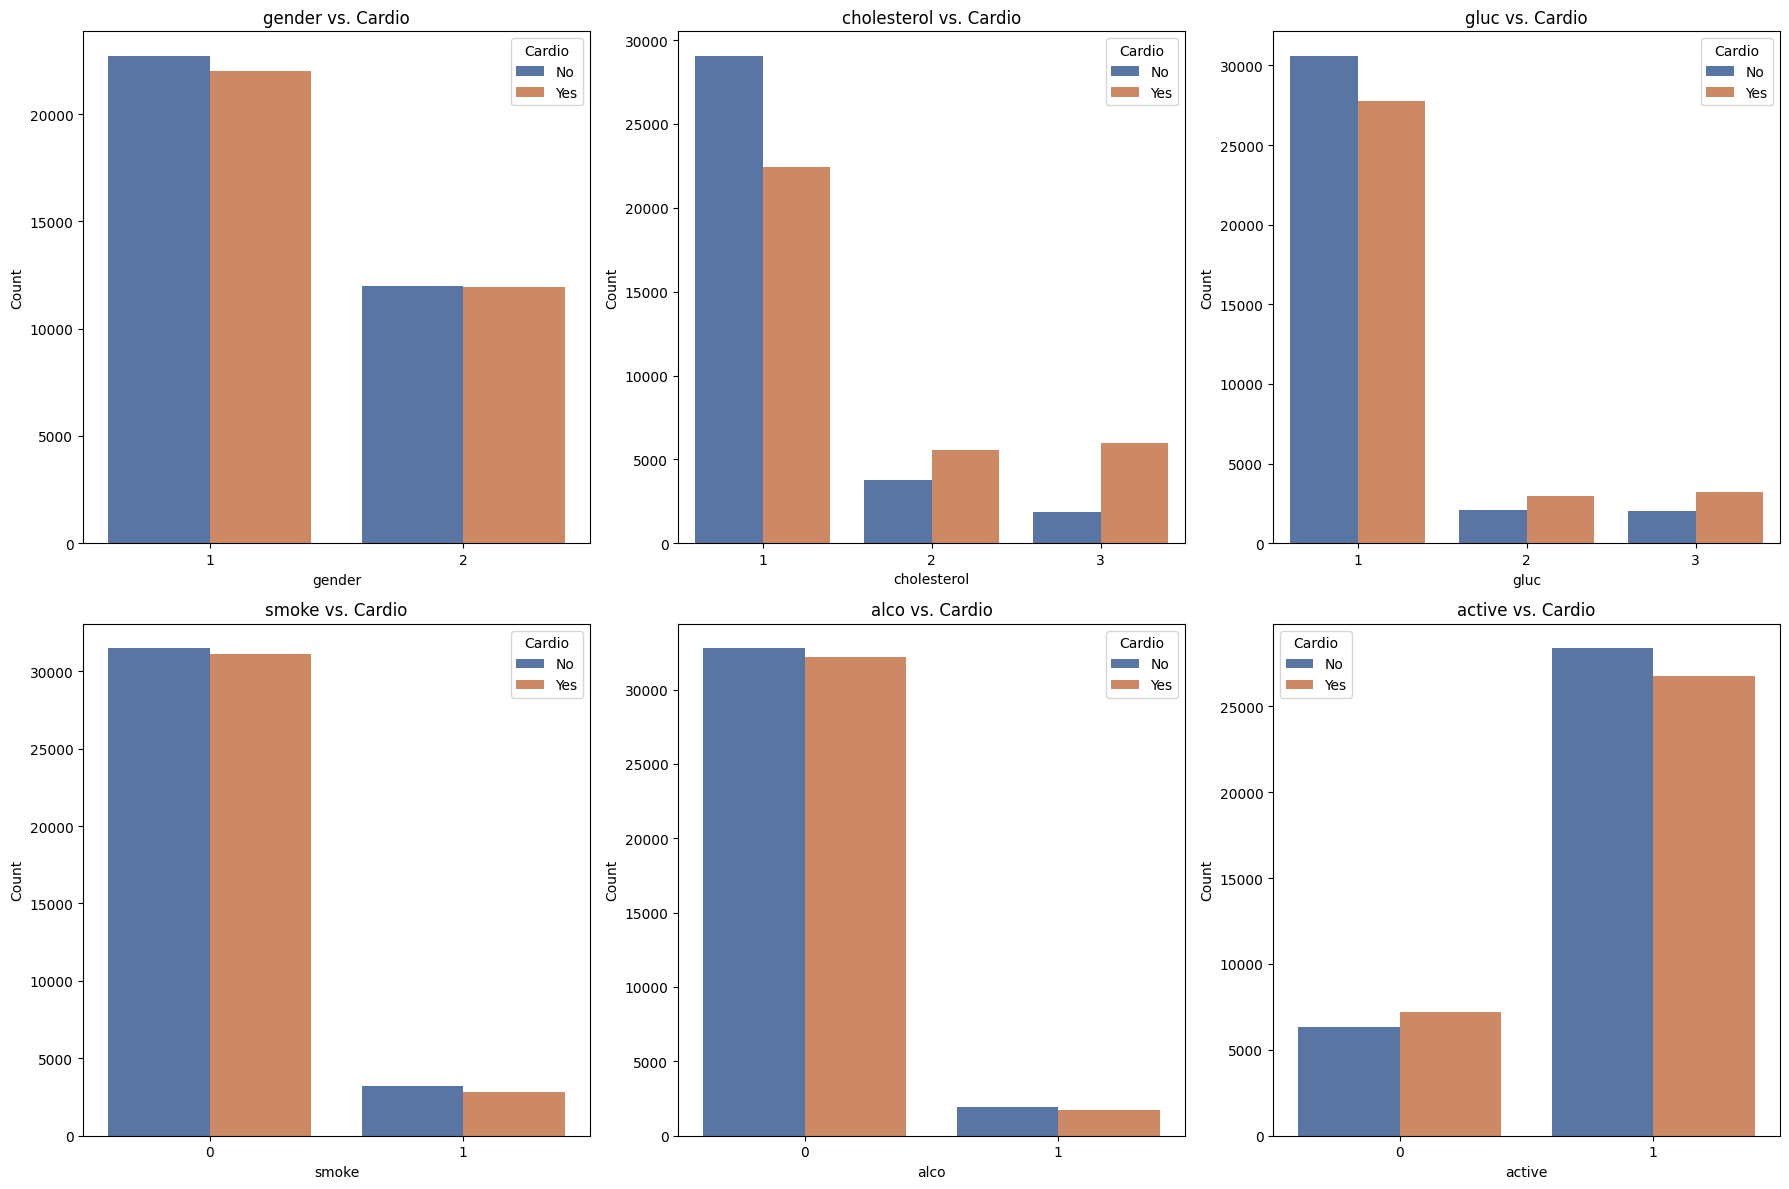

In [27]:
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    sns.countplot(x=col, hue='cardio', data=df, ax=axes[i], palette='deep')
    axes[i].set_title(f'{col} vs. Cardio')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Cardio', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

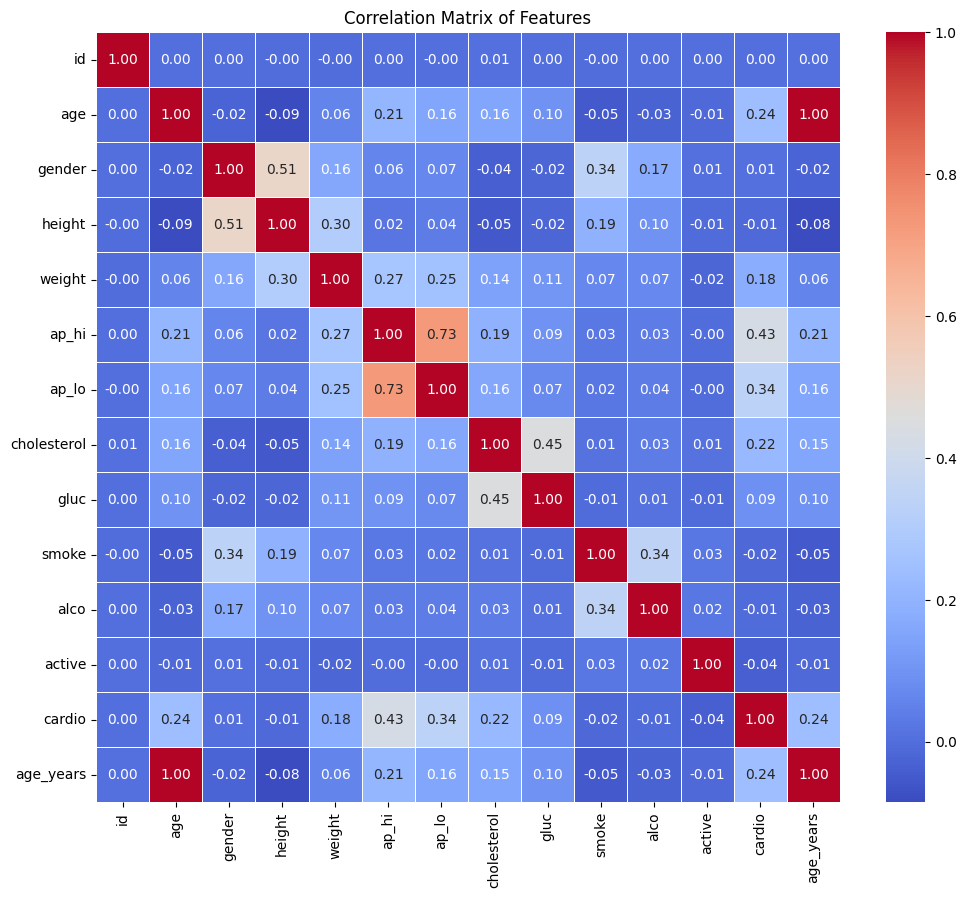

In [28]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(['id', 'age', 'cardio'], axis=1)
y = df['cardio']

numerical_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']

scaler = StandardScaler()

X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train.head()

X_train shape: (54918, 11)
X_test shape: (13730, 11)
y_train shape: (54918,)
y_test shape: (13730,)


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,age_years
40588,1,-1.556779,0.691943,0.201072,-0.132191,1,1,0,0,1,-2.038901
5884,1,0.577994,-0.987875,0.801317,0.921056,3,1,1,0,1,-1.151857
54713,2,-0.175455,-0.917882,-0.399172,-0.132191,1,1,0,0,1,-1.447539
7003,2,-1.682353,-1.757791,-0.399172,-0.132191,2,1,1,0,1,1.213593
69204,1,0.326844,1.391867,0.201072,0.921056,1,1,0,0,1,0.326549


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model_accuracies = {}
model_reports = {}

lr_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
model_accuracies['Logistic Regression'] = accuracy_lr
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
model_reports['Logistic Regression'] = classification_report(y_test, y_pred_lr, output_dict=True)

Logistic Regression Accuracy: 0.7212

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.70      0.78      0.74      6939
           1       0.75      0.66      0.70      6791

    accuracy                           0.72     13730
   macro avg       0.72      0.72      0.72     13730
weighted avg       0.72      0.72      0.72     13730



In [33]:
svc_model = LinearSVC(random_state=42, dual=True, max_iter=10000)
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
model_accuracies['Support Vector Machine'] = accuracy_svc
print(f"Support Vector Machine Accuracy: {accuracy_svc:.4f}")
print("\nClassification Report for Support Vector Machine:")
print(classification_report(y_test, y_pred_svc))
model_reports['Support Vector Machine'] = classification_report(y_test, y_pred_svc, output_dict=True)


Training Support Vector Machine (LinearSVC). This may take a while...
Support Vector Machine Accuracy: 0.7202

Classification Report for Support Vector Machine:
              precision    recall  f1-score   support

           0       0.70      0.79      0.74      6939
           1       0.75      0.65      0.70      6791

    accuracy                           0.72     13730
   macro avg       0.72      0.72      0.72     13730
weighted avg       0.72      0.72      0.72     13730



In [37]:
print("\nTraining K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
model_accuracies['K-Nearest Neighbors'] = accuracy_knn
print(f"K-Nearest Neighbors Accuracy: {accuracy_knn:.4f}")
print("\nClassification Report for K-Nearest Neighbors:")
print(classification_report(y_test, y_pred_knn))
model_reports['K-Nearest Neighbors'] = classification_report(y_test, y_pred_knn, output_dict=True)


Training K-Nearest Neighbors...
K-Nearest Neighbors Accuracy: 0.6910

Classification Report for K-Nearest Neighbors:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70      6939
           1       0.69      0.67      0.68      6791

    accuracy                           0.69     13730
   macro avg       0.69      0.69      0.69     13730
weighted avg       0.69      0.69      0.69     13730



In [36]:
print("\nTraining Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
model_accuracies['Decision Tree'] = accuracy_dt
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print("\nClassification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dt))
model_reports['Decision Tree'] = classification_report(y_test, y_pred_dt, output_dict=True)


Training Decision Tree...
Decision Tree Accuracy: 0.6369

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.64      0.66      0.65      6939
           1       0.64      0.62      0.63      6791

    accuracy                           0.64     13730
   macro avg       0.64      0.64      0.64     13730
weighted avg       0.64      0.64      0.64     13730



In [35]:
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
model_accuracies['Random Forest'] = accuracy_rf
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("\nClassification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))
model_reports['Random Forest'] = classification_report(y_test, y_pred_rf, output_dict=True)


Training Random Forest...
Random Forest Accuracy: 0.7003

Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.70      0.71      0.71      6939
           1       0.70      0.69      0.69      6791

    accuracy                           0.70     13730
   macro avg       0.70      0.70      0.70     13730
weighted avg       0.70      0.70      0.70     13730




Accuracy Scores:

| Model                  |   Accuracy |
|:-----------------------|-----------:|
| Logistic Regression    |   0.721194 |
| Support Vector Machine |   0.720248 |
| Random Forest          |   0.700291 |
| K-Nearest Neighbors    |   0.690969 |
| Decision Tree          |   0.636854 |


/tmp/ipykernel_1559/2349111221.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=accuracies_df, palette='viridis')


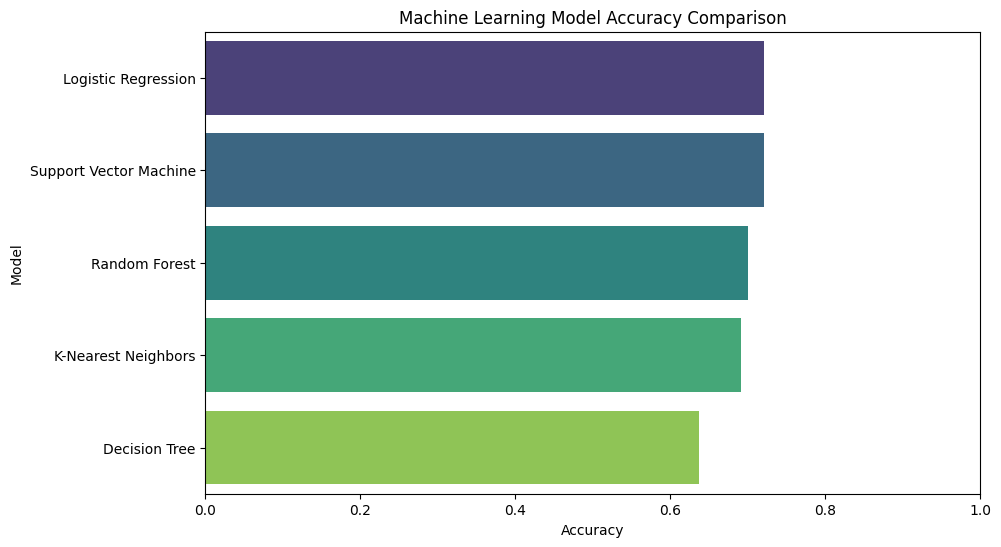

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

accuracies_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy'])
accuracies_df = accuracies_df.sort_values(by='Accuracy', ascending=False)
print("\nAccuracy Scores:\n")
print(accuracies_df.to_markdown(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=accuracies_df, palette='viridis')
plt.title('Machine Learning Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.show()


Confusion Matrix for Random Forest:


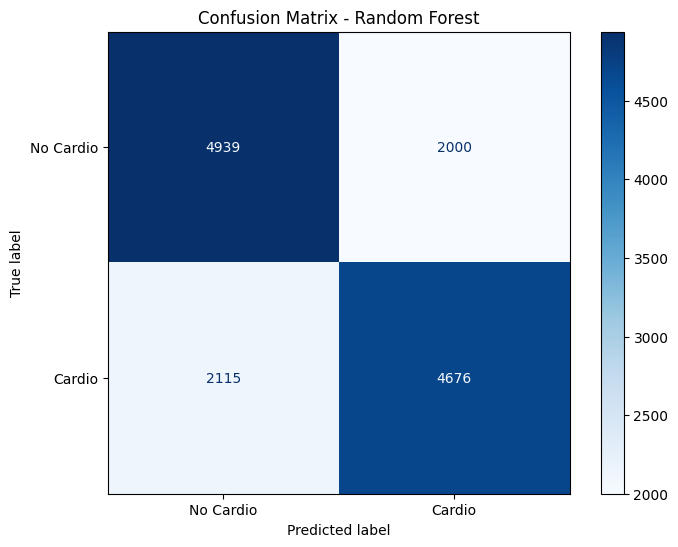

In [39]:
from sklearn.metrics import ConfusionMatrixDisplay

print("\nConfusion Matrix for Random Forest:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
cmd_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['No Cardio', 'Cardio'])
fig, ax = plt.subplots(figsize=(8, 6))
cmd_rf.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()


Feature Importances (Random Forest):

| feature     |   importance |
|:------------|-------------:|
| weight      |   0.232922   |
| height      |   0.211607   |
| ap_hi       |   0.195299   |
| age_years   |   0.165272   |
| ap_lo       |   0.0842342  |
| cholesterol |   0.0399169  |
| gluc        |   0.0192933  |
| gender      |   0.0180062  |
| active      |   0.0154121  |
| smoke       |   0.00981831 |
| alco        |   0.00821856 |


/tmp/ipykernel_1559/2522407941.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')


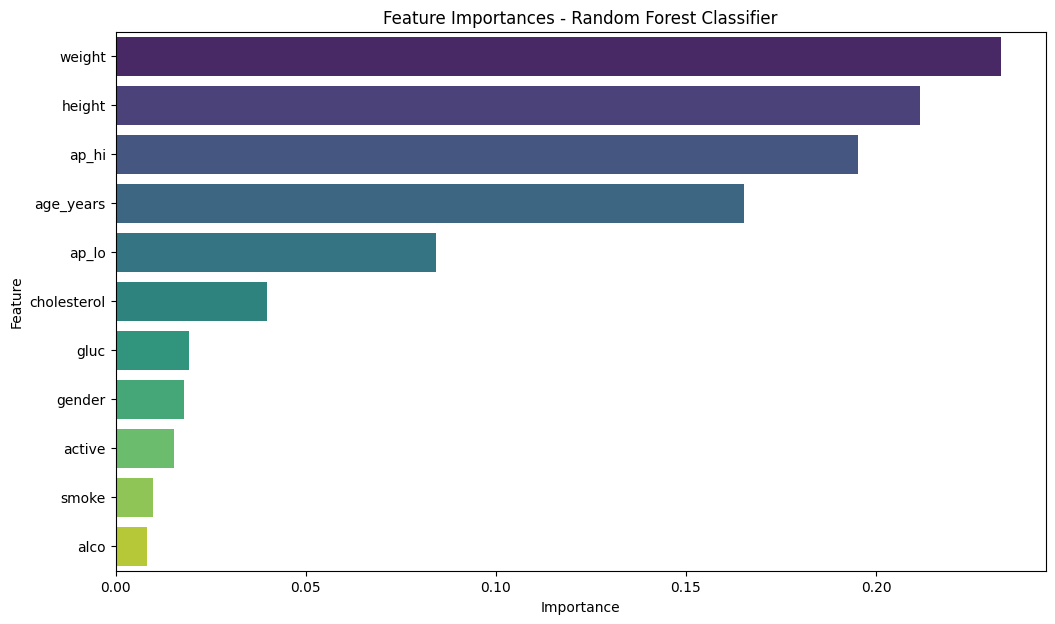

In [43]:

feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nFeature Importances (Random Forest):\n")
print(feature_importances.to_markdown(index=False))

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')
plt.title('Feature Importances - Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [41]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}


grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,scoring='accuracy', n_jobs=-1, verbose=1
)

grid_search_rf.fit(X_train, y_train)

print("\nBest parameters found:", grid_search_rf.best_params_)
print("Best accuracy found:", grid_search_rf.best_score_)

best_rf_model = grid_search_rf.best_estimator_

y_pred_best_rf = best_rf_model.predict(X_test)
accuracy_best_rf = accuracy_score(y_test, y_pred_best_rf)

print(f"\nAccuracy of the best Random Forest model on the test set: {accuracy_best_rf:.4f}")
print("\nClassification Report for the best Random Forest model:")
print(classification_report(y_test, y_pred_best_rf))

Starting GridSearchCV for Random Forest. This may take a while...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Best parameters found: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best accuracy found: 0.7350595433191303

Accuracy of the best Random Forest model on the test set: 0.7288

Classification Report for the best Random Forest model:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6939
           1       0.76      0.66      0.71      6791

    accuracy                           0.73     13730
   macro avg       0.73      0.73      0.73     13730
weighted avg       0.73      0.73      0.73     13730



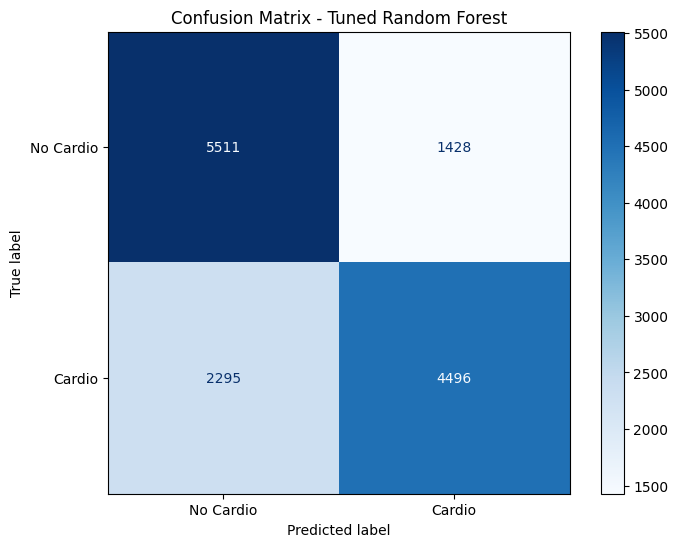

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
cmd_best_rf = ConfusionMatrixDisplay(cm_best_rf, display_labels=['No Cardio', 'Cardio'])

fig, ax = plt.subplots(figsize=(8, 6))
cmd_best_rf.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model_accuracies = {}

lr_model = LogisticRegression(random_state=42, solver='liblinear')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
model_accuracies['Logistic Regression'] = accuracy_lr
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")

Logistic Regression Accuracy: 0.7212


In [59]:
from sklearn.svm import LinearSVC
svc_model = LinearSVC(random_state=42, dual=False, max_iter=10000)
svc_model.fit(X_train, y_train)
y_pred_svc = svc_model.predict(X_test)
accuracy_svc = accuracy_score(y_test, y_pred_svc)
model_accuracies['Support Vector Machine'] = accuracy_svc
print(f"Support Vector Machine Accuracy: {accuracy_svc:.4f}")

Support Vector Machine Accuracy: 0.7202


In [57]:
print("\nTraining K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
model_accuracies['K-Nearest Neighbors'] = accuracy_knn
print(f"K-Nearest Neighbors Accuracy: {accuracy_knn:.4f}")


Training K-Nearest Neighbors...
K-Nearest Neighbors Accuracy: 0.6910


In [56]:
print("\nTraining Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
model_accuracies['Decision Tree'] = accuracy_dt
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")


Training Decision Tree...
Decision Tree Accuracy: 0.6369


In [58]:
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
model_accuracies['Random Forest'] = accuracy_rf
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")


Training Random Forest...
Random Forest Accuracy: 0.7003


| Model                  |   Accuracy |
|:-----------------------|-----------:|
| Logistic Regression    |   0.721194 |
| Support Vector Machine |   0.720248 |
| Random Forest          |   0.700291 |
| K-Nearest Neighbors    |   0.690969 |
| Decision Tree          |   0.636854 |


/tmp/ipykernel_1559/1546097709.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=accuracies_df, palette='viridis')


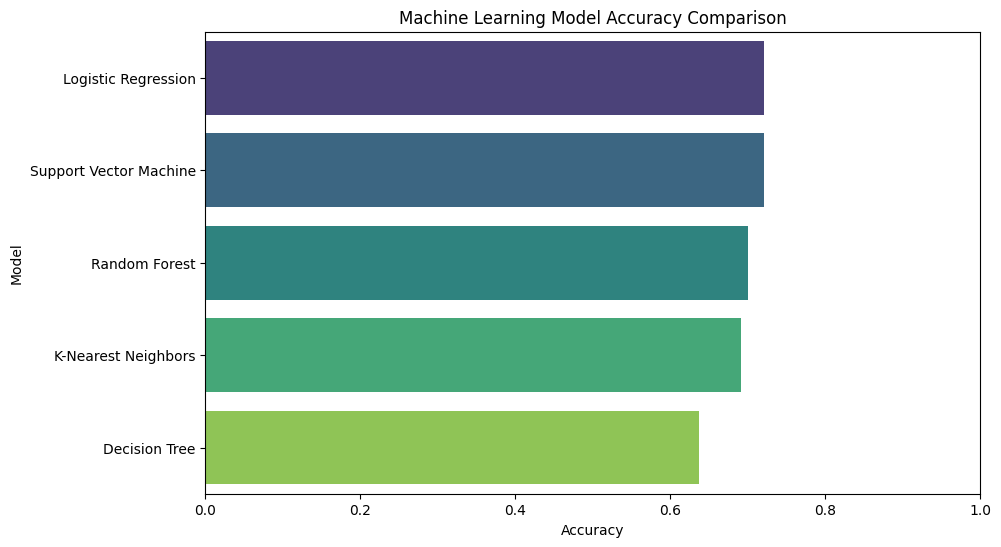

In [54]:
import pandas as pd

accuracies_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy'])
accuracies_df = accuracies_df.sort_values(by='Accuracy', ascending=False)
print(accuracies_df.to_markdown(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=accuracies_df, palette='viridis')
plt.title('Machine Learning Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.show()

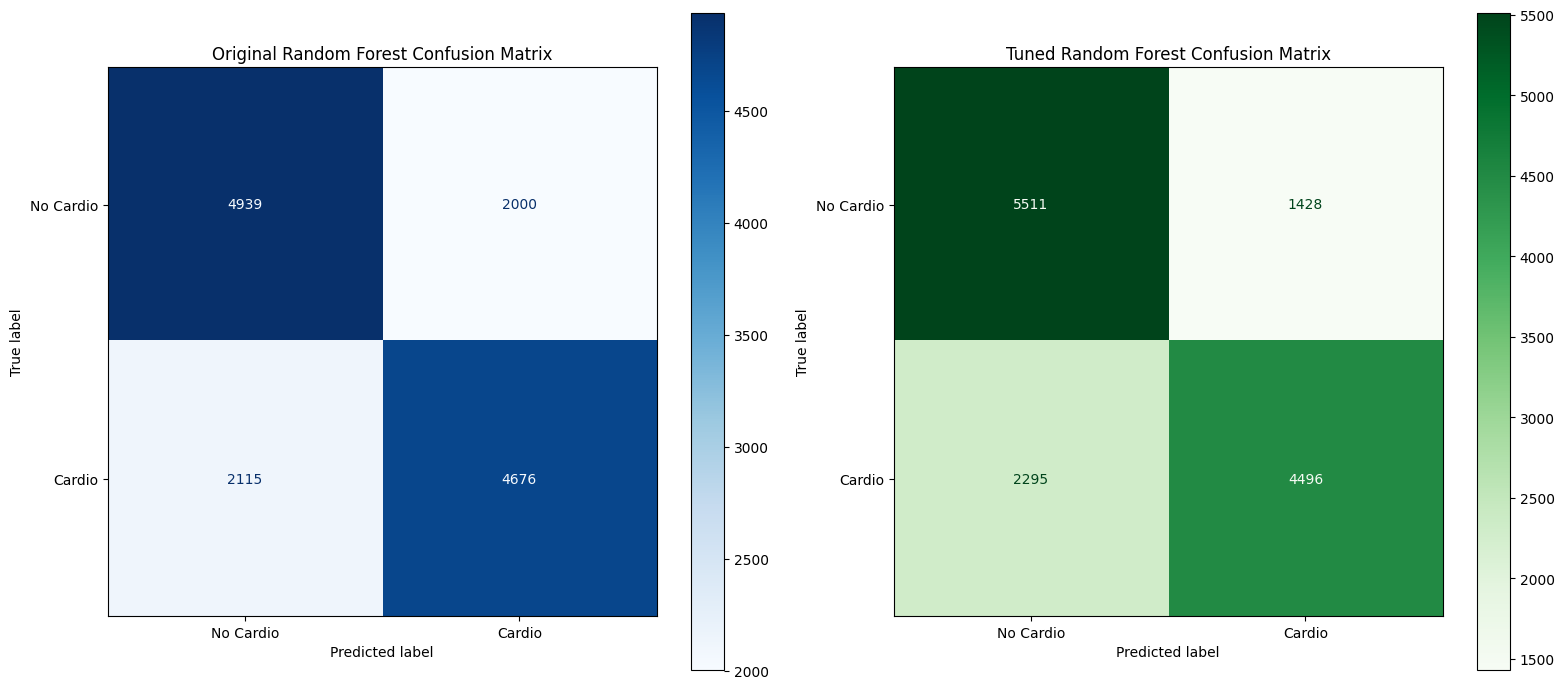

In [52]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

if 'X_test' not in locals() and 'X_test' not in globals():
    print("X_test not found. Re-running data preparation steps...")
    X = df.drop(['id', 'age', 'cardio'], axis=1)
    y = df['cardio']
    numerical_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']
    scaler = StandardScaler()
    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print("Data preparation complete.")

if 'rf_model' not in locals() and 'rf_model' not in globals():
    print("rf_model not found. Re-training original Random Forest model...")
    rf_model = RandomForestClassifier(random_state=42)
    rf_model.fit(X_train, y_train)
    print("Original Random Forest model re-trained.")

if 'y_pred_rf' not in locals() and 'y_pred_rf' not in globals():
    print("y_pred_rf not found. Recalculating predictions for original model...")
    y_pred_rf = rf_model.predict(X_test)
    print("Predictions for original model recalculated.")

if 'cm_rf' not in locals() and 'cm_rf' not in globals():
    print("cm_rf not found. Recalculating confusion matrix for original model...")
    cm_rf = confusion_matrix(y_test, y_pred_rf)
    print("Confusion matrix for original model recalculated.")

if 'best_rf_model' not in locals() and 'best_rf_model' not in globals():
    print("best_rf_model not found. Re-training tuned Random Forest model (this may take a while)...")
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
    grid_search_rf = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    grid_search_rf.fit(X_train, y_train)
    best_rf_model = grid_search_rf.best_estimator_
    print("Tuned Random Forest model re-trained.")

if 'y_pred_best_rf' not in locals() and 'y_pred_best_rf' not in globals():
    print("y_pred_best_rf not found. Recalculating predictions for tuned model...")
    y_pred_best_rf = best_rf_model.predict(X_test)
    print("Predictions for tuned model recalculated.")

if 'cm_best_rf' not in locals() and 'cm_best_rf' not in globals():
    print("cm_best_rf not found. Recalculating confusion matrix for tuned model...")
    cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)
    print("Confusion matrix for tuned model recalculated.")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

cmd_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['No Cardio', 'Cardio'])
cmd_rf.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Original Random Forest Confusion Matrix')

cmd_best_rf = ConfusionMatrixDisplay(cm_best_rf, display_labels=['No Cardio', 'Cardio'])
cmd_best_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Tuned Random Forest Confusion Matrix')

plt.tight_layout()
plt.show()

In [50]:
import numpy as np

new_patient_data = pd.DataFrame({
    'gender': [1],
    'height': [170],
    'weight': [80],
    'ap_hi': [130],
    'ap_lo': [85],
    'cholesterol': [1],
    'gluc': [1],
    'smoke': [0],
    'alco': [0],
    'active': [1],
    'age_years': [55]
})

new_patient_data = new_patient_data[X_train.columns]

numerical_cols_for_scaling = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']
new_patient_data[numerical_cols_for_scaling] = scaler.transform(new_patient_data[numerical_cols_for_scaling])


prediction = best_rf_model.predict(new_patient_data)
prediction_proba = best_rf_model.predict_proba(new_patient_data)[:, 1]

print(f"Predicted cardiovascular disease risk for the new patient: {'Yes' if prediction[0] == 1 else 'No'}")
print(f"Probability of cardiovascular disease: {prediction_proba[0]:.2f}")


Predicted cardiovascular disease risk for the new patient: Yes
Probability of cardiovascular disease: 0.52


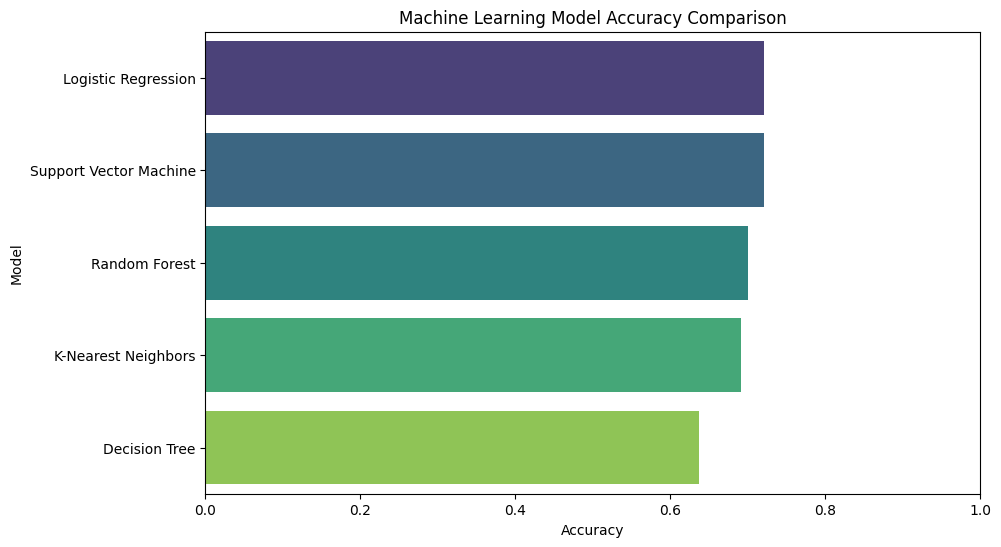

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

accuracies_df = accuracies_df.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=accuracies_df, palette='viridis', hue='Model', legend=False)
plt.title('Machine Learning Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1)
plt.show()

In [48]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

if 'X_test' not in locals() and 'X_test' not in globals():
    print("X_test not found. Re-running data preparation steps...")
    X = df.drop(['id', 'age', 'cardio'], axis=1)
    y = df['cardio']
    numerical_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']
    scaler = StandardScaler()
    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print("Data preparation complete.")

if 'best_rf_model' not in locals() and 'best_rf_model' not in globals():
    print("best_rf_model not found. Re-training tuned Random Forest model (this may take a while)...")
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
    grid_search_rf = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    grid_search_rf.fit(X_train, y_train)
    best_rf_model = grid_search_rf.best_estimator_
    print("Tuned Random Forest model re-trained.")

if 'y_pred_best_rf' not in locals() and 'y_pred_best_rf' not in globals():
    print("y_pred_best_rf not found. Recalculating predictions for tuned model...")
    y_pred_best_rf = best_rf_model.predict(X_test)
    print("Predictions for tuned model recalculated.")

print("Classification Report for the Tuned Random Forest Model:")
print(classification_report(y_test, y_pred_best_rf))

Classification Report for the Tuned Random Forest Model:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6939
           1       0.76      0.66      0.71      6791

    accuracy                           0.73     13730
   macro avg       0.73      0.73      0.73     13730
weighted avg       0.73      0.73      0.73     13730



In [46]:
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

if 'X_test' not in locals() and 'X_test' not in globals():
    print("X_test not found. Re-running data preparation steps...")
    X = df.drop(['id', 'age', 'cardio'], axis=1)
    y = df['cardio']
    numerical_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']
    scaler = StandardScaler()
    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print("Data preparation complete.")

if 'best_rf_model' not in locals() and 'best_rf_model' not in globals():
    print("best_rf_model not found. Re-training tuned Random Forest model (this may take a while)...")
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
    grid_search_rf = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    grid_search_rf.fit(X_train, y_train)
    best_rf_model = grid_search_rf.best_estimator_
    print("Tuned Random Forest model re-trained.")

if 'y_pred_best_rf' not in locals() and 'y_pred_best_rf' not in globals():
    print("y_pred_best_rf not found. Recalculating predictions for tuned model...")
    y_pred_best_rf = best_rf_model.predict(X_test)
    print("Predictions for tuned model recalculated.")

f1_tuned_rf = f1_score(y_test, y_pred_best_rf)
print(f"F1-Score for the Tuned Random Forest Model: {f1_tuned_rf:.4f}")

F1-Score for the Tuned Random Forest Model: 0.7072


AUC for the Tuned Random Forest Model: 0.7975


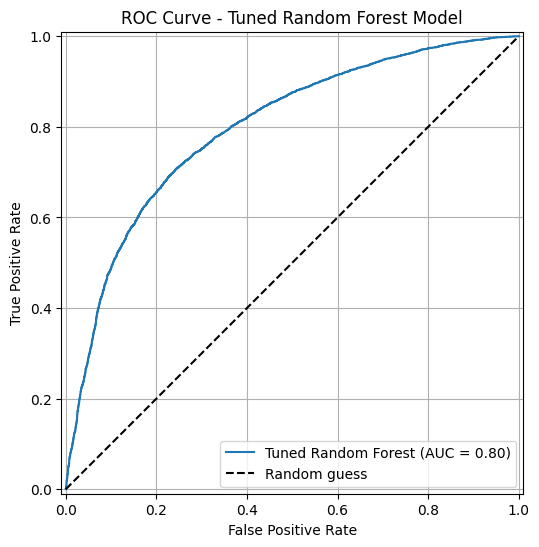

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_pred_proba_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best_rf)

auc_best_rf = roc_auc_score(y_test, y_pred_proba_best_rf)

print(f"AUC for the Tuned Random Forest Model: {auc_best_rf:.4f}")

fig, ax = plt.subplots(figsize=(8, 6))
roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_best_rf, estimator_name='Tuned Random Forest')
roc_display.plot(ax=ax)
plt.title('ROC Curve - Tuned Random Forest Model')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.legend(loc='lower right')
plt.show()

Ensuring original Random Forest model is trained...
Original Random Forest model trained.
AUC for the Original Random Forest Model: 0.7598


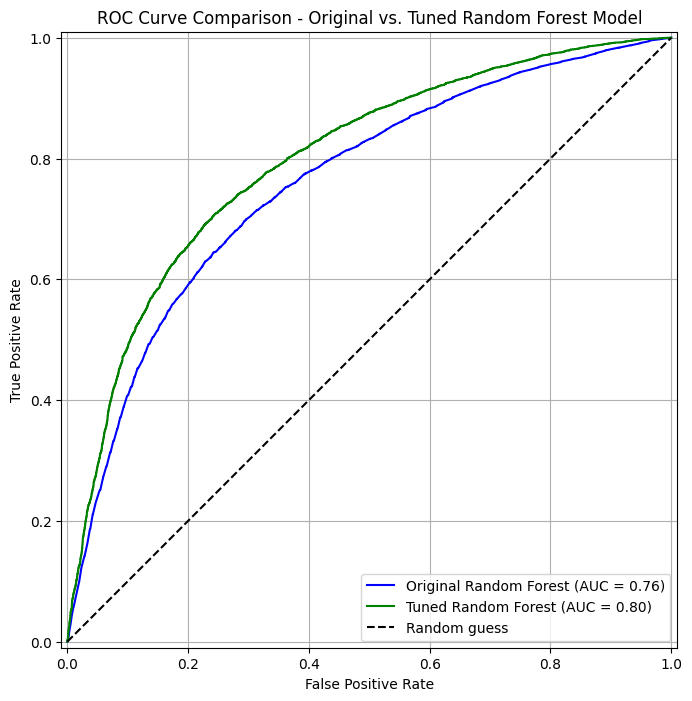

In [49]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

if 'X_train' not in locals() and 'X_train' not in globals():
    print("X_train not found. Re-running data preparation steps from cell 4c27ffc6...")


    X = df.drop(['id', 'age', 'cardio'], axis=1)
    y = df['cardio']

    numerical_cols = ['height', 'weight', 'ap_hi', 'ap_lo', 'age_years']

    scaler = StandardScaler()

    X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print("Data preparation complete: X_train, y_train, X_test, y_test, scaler are now defined.")

print("Ensuring original Random Forest model is trained...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Original Random Forest model trained.")

if 'best_rf_model' not in locals() and 'best_rf_model' not in globals():
    print("best_rf_model not found. Re-training tuned Random Forest model (this may take a while)...")
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    }
    grid_search_rf = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        param_grid=param_grid,
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )
    grid_search_rf.fit(X_train, y_train)
    best_rf_model = grid_search_rf.best_estimator_
    print("Tuned Random Forest model re-trained.")

if 'fpr' not in locals() and 'fpr' not in globals() or \
   'tpr' not in locals() and 'tpr' not in globals() or \
   'auc_best_rf' not in locals() and 'auc_best_rf' not in globals():
    print("Tuned model ROC curve data not found. Recalculating...")
    y_pred_proba_best_rf = best_rf_model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best_rf)
    auc_best_rf = roc_auc_score(y_test, y_pred_proba_best_rf)
    print("Tuned model ROC curve data recalculated.")


y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"AUC for the Original Random Forest Model: {auc_rf:.4f}")

fig, ax = plt.subplots(figsize=(10, 8))

roc_display_rf = RocCurveDisplay(fpr=fpr_rf, tpr=tpr_rf, roc_auc=auc_rf, estimator_name='Original Random Forest')
roc_display_rf.plot(ax=ax, color='blue')

roc_display_best_rf = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc_best_rf, estimator_name='Tuned Random Forest')
roc_display_best_rf.plot(ax=ax, color='green')

plt.title('ROC Curve Comparison - Original vs. Tuned Random Forest Model')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid(True)
plt.legend(loc='lower right')
plt.show()